<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 16 - Ejemplo 1 - Árboles de decisión
        </td>
    </tr>
    <tr>
 

</table>

Para explicar el funcionamiento de un árbol de decisión, empezaremos utilizando un
problema de clasificación, y posteriormente veremos su contrapartida en el modelo de
regresión. En concreto, se va a emplear el conjunto de datos Iris, que es un conjunto
de datos muy empleado en multitud de manuales y softwares estadísticos. El conjunto
de datos Iris consiste en diferentes medidas sobre 150 flores de 3 especias distintas:
Iris Setosa, Iris versicolor y Iris virginica. Este conjunto de datos se puede encontrar
en el paquete Scikit-learn y para acceder a su contenido debemos importar la función
load_iris del modulo sklearn.datasets. Realizar árboles de decisión considerando lo siguiente


a) Sin ningún tipo de restricciones.

b) Indicando que el nivel de profundidad máximo permitido es de 3.

c) Indicando que el mínimo número de observaciones que debe contener cada nodo
hoja es de 5.

In [1]:
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import seaborn as sns

from collections import deque
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import _tree as ctree
from matplotlib.patches import Rectangle

In [2]:
#Cargar librerias
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

In [3]:
#Cargar dataset
iris = load_iris()

#Seleccionar longitud y anchura del petalo
X = iris.data[:, 2:]
#Especie de la planta
y = iris.target

#Crear el objeto de clase arbol
tree_clf = DecisionTreeClassifier(random_state=2026)
#Ajustar el árbol
tree_clf.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [7]:
from graphviz import Source
from sklearn.tree import export_graphviz

#Definir donde vamos a guardar la figura
ROOT_DIR = "."
PATH_FIGURAS = os.path.join(ROOT_DIR, "images")
os.makedirs(PATH_FIGURAS, exist_ok=True)
export_graphviz(tree_clf, out_file = os.path.join(PATH_FIGURAS, "arbol_iris.dot"), feature_names = iris.feature_names[2:],
class_names = iris.target_names, rounded = True, filled = True)

[Text(0.5, 0.9166666666666666, 'x[0] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4090909090909091, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.4545454545454546, 0.8333333333333333, 'True  '),
 Text(0.5909090909090909, 0.75, 'x[1] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5454545454545454, 0.8333333333333333, '  False'),
 Text(0.36363636363636365, 0.5833333333333334, 'x[0] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.18181818181818182, 0.4166666666666667, 'x[1] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.09090909090909091, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.2727272727272727, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.5454545454545454, 0.4166666666666667, 'x[1] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.45454545454545453, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.6363636363636364, 0.25, 'x

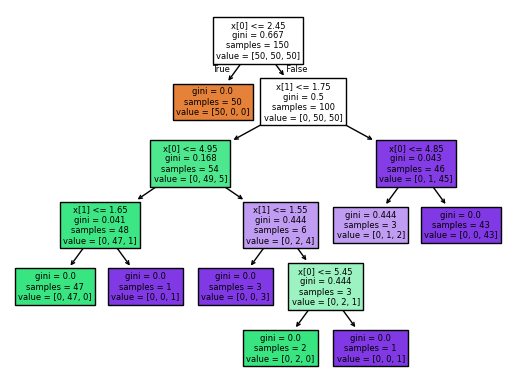

In [8]:
from sklearn import tree
tree.plot_tree(tree_clf,filled=True)

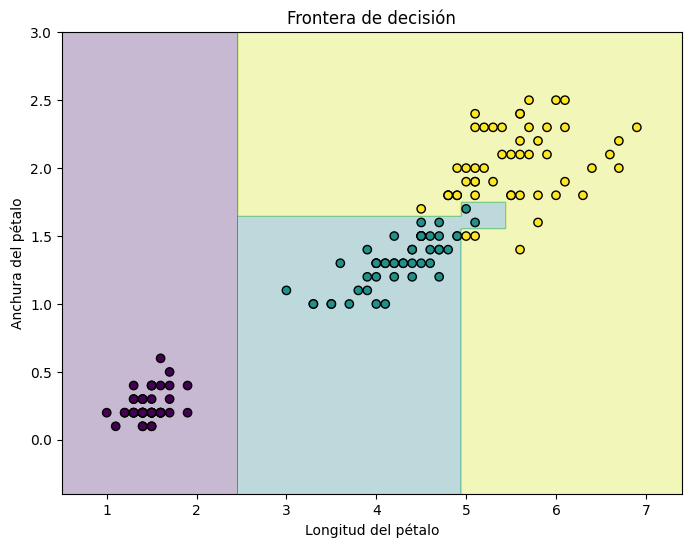

In [9]:
# Crear malla de puntos
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),  np.linspace(y_min, y_max, 500))

# Predecir en cada punto de la malla
Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar frontera de decisión
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Graficar datos reales
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")

plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Frontera de decisión")
plt.show()

In [10]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_1 = tree_clf.predict(X)
accuracy_1 = accuracy_score(y, y_pred_1)
print("El accuracy score que se tiene es %s" %accuracy_1)

El accuracy score que se tiene es 0.9933333333333333


Text(50.722222222222214, 0.5, 'Real')

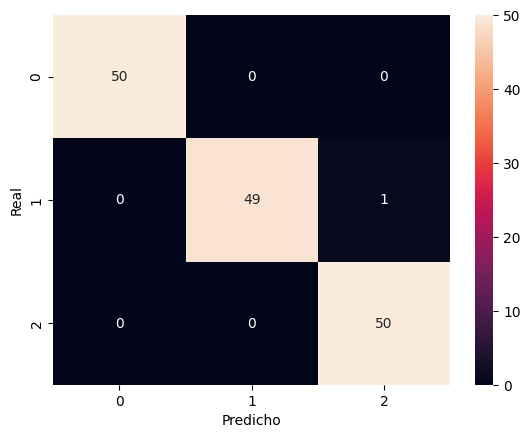

In [11]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y, y_pred_1)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_1 = precision_score(y, y_pred_1,average="macro")
recall_1 = recall_score(y, y_pred_1, average="macro")
f1_1 = f1_score(y, y_pred_1, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_1, recall_1,f1_1]})
metricas

,Métricas,Valores
0,Precisión,0.993464
1,Recall,0.993333
2,F1,0.993333


LITERAL B

In [26]:
# b)
#Crear el objeto de clase arbol
tree_clf_b =  DecisionTreeClassifier(max_depth=3, random_state=2026)
# Ajustar el arbol
tree_clf_b.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.375, 0.875, 'x[0] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[1] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[0] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.125, 0.125, 'gini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.375, 0.125, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.75, 0.375, 'x[0] <= 4.85\ngini = 0.043\nsamples = 46\nvalue = [0, 1, 45]'),
 Text(0.625, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 43\nvalue = [0, 0, 43]')]

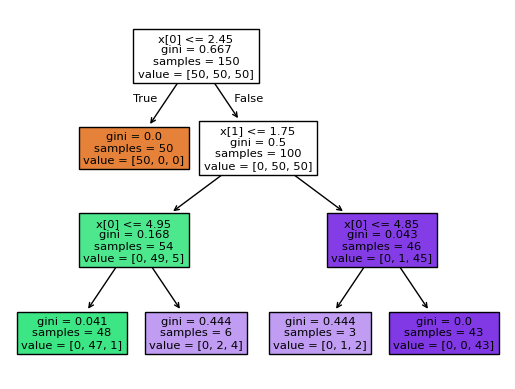

In [27]:
tree.plot_tree(tree_clf_b, filled=True)

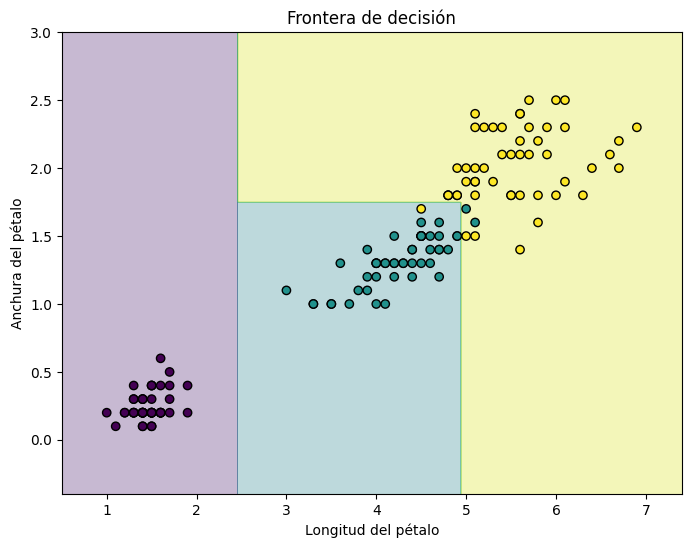

In [28]:
# Crear malla de puntos
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),  np.linspace(y_min, y_max, 500))

# Predecir en cada punto de la malla
Z = tree_clf_b.predict(np.c_[xx.ravel(), yy.ravel()]) #b
Z = Z.reshape(xx.shape)

# Graficar frontera de decisión
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Graficar datos reales
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")

plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Frontera de decisión")
plt.show()

In [29]:
#obtener el accuracy_score
y_pred_b= tree_clf_b.predict(X)
accuracy_b = accuracy_score(y, y_pred_b)
print("El accuracy score que se tiene es %s" %accuracy_b)

El accuracy score que se tiene es 0.9733333333333334


Text(50.722222222222214, 0.5, 'Real')

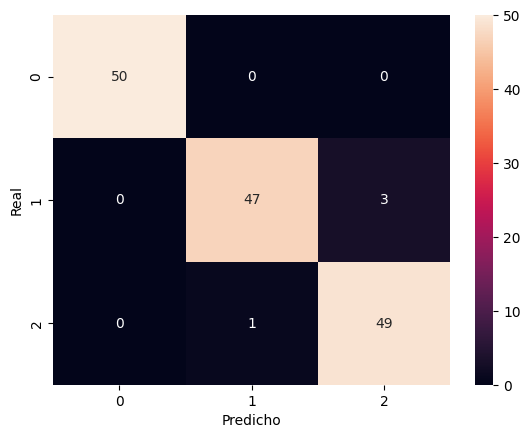

In [30]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y, y_pred_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_b = precision_score(y, y_pred_b,average="macro")
recall_b = recall_score(y, y_pred_b, average="macro")
f1_b = f1_score(y, y_pred_b, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_b, recall_b,f1_b]})
metricas

,Métricas,Valores
0,Precisión,0.973825
1,Recall,0.973333
2,F1,0.973323


**c) Indicando que el mínimo número de observaciones debe conteneer cada nodo hoja es de 5.**

In [39]:
#Crear el objeto de clase arbol
tree_clf_c =  DecisionTreeClassifier(min_samples_leaf=5, random_state=2026) #5 muestras
# Ajustar el arbol
tree_clf_c.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.4444444444444444, 0.9166666666666666, 'x[0] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.3333333333333333, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.38888888888888884, 0.8333333333333333, 'True  '),
 Text(0.5555555555555556, 0.75, 'x[1] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5, 0.8333333333333333, '  False'),
 Text(0.3333333333333333, 0.5833333333333334, 'x[0] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.2222222222222222, 0.4166666666666667, 'x[1] <= 1.45\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 35\nvalue = [0, 35, 0]'),
 Text(0.3333333333333333, 0.25, 'x[0] <= 4.55\ngini = 0.142\nsamples = 13\nvalue = [0, 12, 1]'),
 Text(0.2222222222222222, 0.08333333333333333, 'gini = 0.219\nsamples = 8\nvalue = [0, 7, 1]'),
 Text(0.4444444444444444, 0.08333333333333333, 'gini = 0.0\nsamples = 5\nvalue = [0, 5, 0]'),
 Text(0.444444444

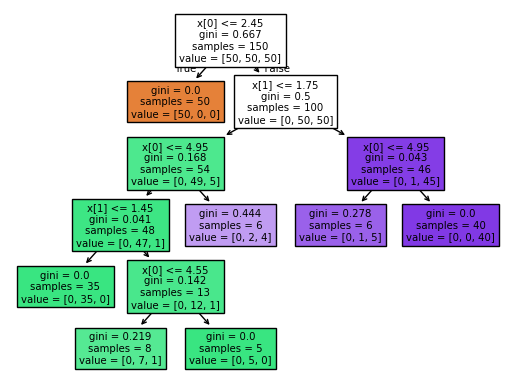

In [40]:
tree.plot_tree(tree_clf_c, filled=True)

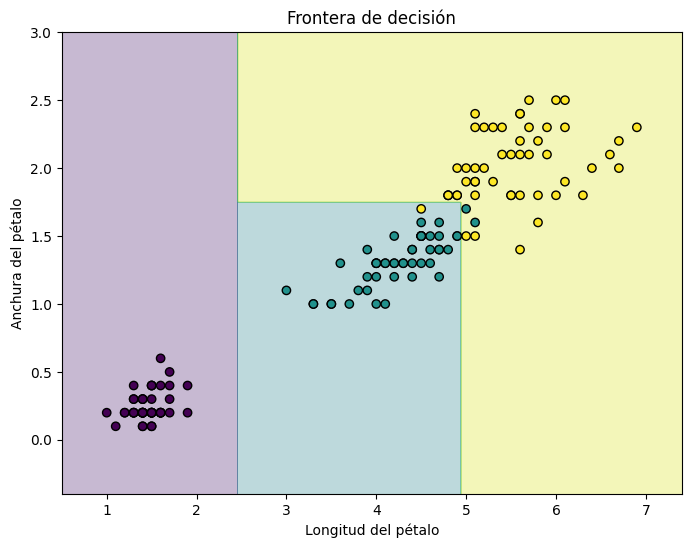

In [41]:
# Crear malla de puntos
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),  np.linspace(y_min, y_max, 500))

# Predecir en cada punto de la malla
Z = tree_clf_c.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar frontera de decisión
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Graficar datos reales
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")

plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Frontera de decisión")
plt.show()

In [42]:
#obtener el accuracy_score
y_pred_c= tree_clf_c.predict(X)
accuracy_c = accuracy_score(y, y_pred_c)
print("El accuracy score que se tiene es %s" %accuracy_c)

El accuracy score que se tiene es 0.9733333333333334


Text(50.722222222222214, 0.5, 'Real')

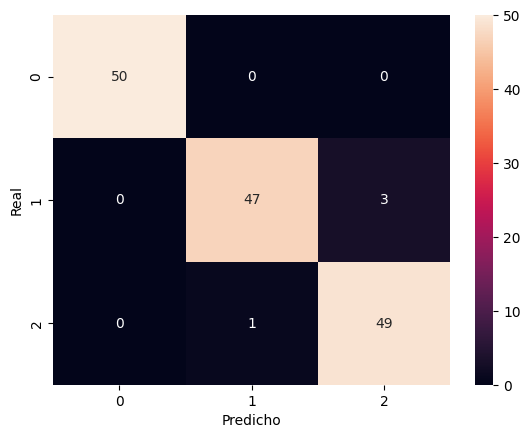

In [43]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y, y_pred_c)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_c = precision_score(y, y_pred_c,average="macro")
recall_c = recall_score(y, y_pred_c, average="macro")
f1_c = f1_score(y, y_pred_c, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_c, recall_c,f1_c]})
metricas

,Métricas,Valores
0,Precisión,0.973825
1,Recall,0.973333
2,F1,0.973323
